# Tugas 2 - Deep Learning: Replikasi & Eksperimen Regularisasi MNIST

**Identitas Mahasiswa:**
- **Nama:** Dhimas Putra Sulistio
- **NIM:** 24/537952/PA/22811

---

## Deskripsi Tugas & Ruang Lingkup
Notebook ini merupakan pengerjaan komprehensif untuk **Tugas 2 Deep Learning** yang mencakup:
1. **Nomor 1: Replikasi Model Klasifikasi MNIST (Slide 14–23)**
   - Replikasi alur dasar Keras Sequential API untuk klasifikasi angka tulisan tangan MNIST.
   - Prapemrosesan data, perancangan arsitektur baseline (Flatten $\rightarrow$ Dense(64, ReLU) $\rightarrow$ Dense(10, Softmax)), pelatihan, visualisasi evaluasi, penyimpanan model, dan inferensi.
2. **Nomor 2: Eksperimen Strategi Pembelajaran & Penanganan Overfitting**
   - **2(a) Regularisasi L1 (Lasso):** Menambahkan penalti norm-$L_1$ pada bobot kernel layer tersembunyi guna mendorong sparsitas bobot.
   - **2(b) Regularisasi L2 (Ridge / Weight Decay):** Menambahkan penalti kuadrat norm-$L_2$ guna mencegah bobot bernilai terlalu ekstrem.
   - **2(c) Dropout:** Menerapkan regularisasi struktural dengan menonaktifkan neuron tersembunyi secara acak saat fase pelatihan untuk mencegah ko-adaptasi.
   - **2(d) Early Stopping:** Menerapkan mekanisme penghentian iterasi pelatihan secara otomatis saat *validation loss* tidak lagi menunjukkan perbaikan untuk mencegah *overfitting*.
   - **2(e) Kombinasi L1 Regularization dan Dropout:** Menganalisis interaksi simultan antara penalti norm-$L_1$ dan teknik penonaktifan neuron *Dropout*.
3. **Analisis Komparasi Menyeluruh & Distribusi Bobot:**
   - Tabel perbandingan komprehensif seluruh skenario (parameter, loss, akurasi, dan *generalization gap*).
   - Grafik gabungan (*overlay plot*) kurva validasi untuk membandingkan kecepatan konvergensi dan stabilitas.
   - Histogram distribusi bobot (*weight distribution*) untuk membuktikan secara empiris fenomena sparsitas pada L1 dan penyusutan (*shrinkage*) pada L2.
4. **Panduan Pembuatan Slide Presentasi (Nomor 3):**
   - Ringkasan terstruktur halaman demi halaman (Slide 1–8) sesuai format yang diminta pada berkas tugas.


---
## 0. Import Library dan Konfigurasi Reproduksibilitas
Kita memuat seluruh modul yang diperlukan: `tensorflow`, `keras`, `numpy`, `matplotlib`, serta modul regularizers dan callbacks. Kita juga mengatur *random seed* agar seluruh hasil eksperimen bersifat deterministik dan dapat direproduksi secara konsisten.


In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Mengatur random seed untuk menjamin reproduksibilitas eksperimen
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Import modul Keras
import keras
from keras.models import Sequential, load_model
from keras.layers import Flatten, Dense, Dropout
from keras.regularizers import l1, l2
from keras.callbacks import EarlyStopping
from keras.datasets import mnist
from keras.utils import to_categorical

# Konfigurasi visualisasi matplotlib
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

print("TensorFlow Version :", tf.__version__)
print("Keras Version      :", keras.__version__)
print("Semua modul berhasil diimpor dengan lancar.")


TensorFlow Version : 2.21.0
Keras Version      : 3.15.1
Semua modul berhasil diimpor dengan lancar.


---
## 1. Pemuatan & Prapemrosesan Data MNIST

### Spesifikasi Pembagian Data Menurut Slide 17:
Sesuai teks pada **Slide 17**, dataset digit MNIST dibagi menjadi 3 subset:
- **55.000 data training**
- **5.000 data validasi**
- **10.000 data testing**

Prapemrosesan mencakup:
1. *Reshape* array citra menjadi tensor berdimensi `(-1, 28, 28, 1)`.
2. Konversi tipe data ke `float32`.
3. Normalisasi nilai piksel dari rentang $[0, 255]$ ke $[0, 1]$ (`/= 255`).
4. Transformasi label target integer (0–9) menjadi representasi biner *One-Hot Encoded* 10 dimensi.


In [2]:
# Pemuatan data MNIST asli
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

# Normalisasi dan reshaping citra
X_train_full = X_train_full.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Konversi label ke One-Hot Encoding (10 kelas)
y_train_full = to_categorical(y_train_full, 10)
y_test = to_categorical(y_test, 10)

# Pembagian data training menjadi 55.000 data train dan 5.000 data validasi (sesuai Slide 17)
X_train = X_train_full[:55000]
y_train = y_train_full[:55000]

X_val = X_train_full[55000:]
y_val = y_train_full[55000:]

print(f"Dataset MNIST Berhasil Dipisahkan (Sesuai Slide 17):")
print(f"- Data Training   : {X_train.shape[0]:,} sampel | Dimensi: {X_train.shape}")
print(f"- Data Validasi   : {X_val.shape[0]:,} sampel  | Dimensi: {X_val.shape}")
print(f"- Data Testing    : {X_test.shape[0]:,} sampel | Dimensi: {X_test.shape}")
print(f"Rentang nilai piksel: [{X_train.min():.1f}, {X_train.max():.1f}]")


Dataset MNIST Berhasil Dipisahkan (Sesuai Slide 17):
- Data Training   : 55,000 sampel | Dimensi: (55000, 28, 28, 1)
- Data Validasi   : 5,000 sampel  | Dimensi: (5000, 28, 28, 1)
- Data Testing    : 10,000 sampel | Dimensi: (10000, 28, 28, 1)
Rentang nilai piksel: [0.0, 1.0]


### Visualisasi Sampel Citra MNIST
Berikut adalah 10 sampel citra pertama dari subset data latih beserta label angka aslinya:


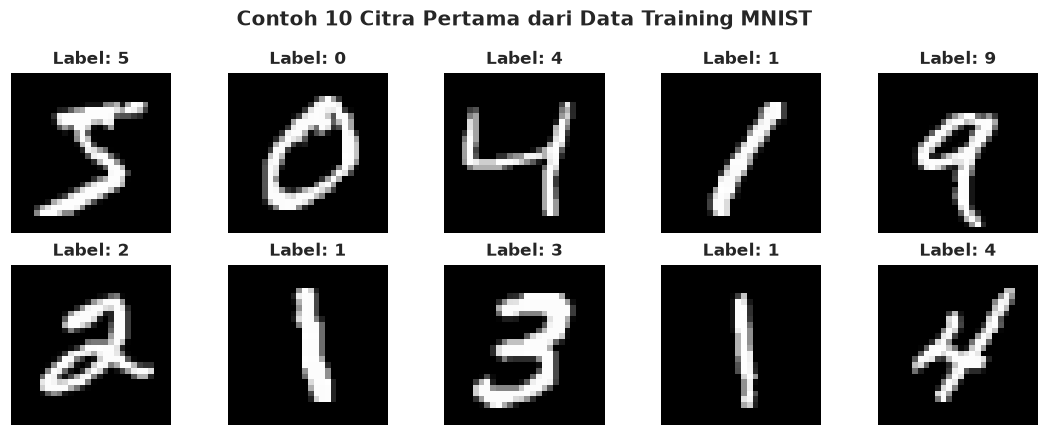

In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}", fontsize=11, fontweight='bold')
    plt.axis('off')
plt.suptitle("Contoh 10 Citra Pertama dari Data Training MNIST", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
# BAGIAN 1

Pada bagian ini, kita mereplikasi model baseline secara presisi mengikuti panduan slide:
- **Arsitektur:**
  - `Flatten(input_shape=(28, 28, 1))` $\rightarrow$ meratakan matriks $28 \times 28 \times 1$ menjadi vektor $784$ fitur ($0$ parameter).
  - `Dense(64, activation='relu')` $\rightarrow$ hidden layer 64 neuron ($784 \times 64 + 64 = 50.240$ parameter).
  - `Dense(10, activation='softmax')` $\rightarrow$ output layer 10 neuron ($64 \times 10 + 10 = 650$ parameter).
  - **Total Trainable Parameters:** $50.890$.
- **Kompilasi:** Optimizer `adam`, loss `categorical_crossentropy`, metrik `acc`.
- **Pelatihan:** 10 epoch, batch size 100, validasi data test (dan data val).
- **Penyimpanan:** Disimpan sebagai `'my_model1.h5'` dan `'my_model.h5'`.
- **Inferensi:** Evaluasi pada data uji dan prediksi sampel indeks ke-30.


In [4]:
# --- Definisi Model Baseline Sesuai Slide 20 ---
model1 = Sequential([
    Flatten(input_shape=(28, 28, 1), name='flatten_input'),
    Dense(64, activation='relu', name='hidden_dense_64'),
    Dense(10, activation='softmax', name='output_dense_10')
], name='Model_1_Baseline')

# Ringkasan arsitektur model
model1.summary()


C:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Model_1_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_input (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_64 (Dense)         │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_10 (Dense)         │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# --- Kompilasi & Pelatihan Model Baseline Sesuai Slide 21 ---
model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['acc']
)

# Pelatihan model selama 10 epoch dengan batch size 100
history1 = model1.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=100,
    validation_data=(X_test, y_test),
    verbose=1
)

# Alias variabel untuk menjaga kompatibilitas penamaan pada slide
history = history1

# Menyimpan model ke format .h5 (Slide 21 & Slide 23)
model1.save('my_model1.h5')
model1.save('my_model.h5')
print("\nModel berhasil disimpan ke berkas 'my_model1.h5' dan 'my_model.h5'.")

# Evaluasi pada data uji
loss_base, acc_base = model1.evaluate(X_test, y_test, verbose=0)
print(f"\nHasil Evaluasi Baseline pada Test Set:")
print(f"Test Loss    : {loss_base:.4f}")
print(f"Test Accuracy: {acc_base * 100:.2f}%")


Epoch 1/10



  1/550 ━━━━━━━━━━━━━━━━━━━━ 14:48 2s/step - acc: 0.1300 - loss: 2.3958


 13/550 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.3362 - loss: 2.0347  


 26/550 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.5242 - loss: 1.6890


 40/550 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.6175 - loss: 1.4166

...


528/550 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9852 - loss: 0.0541


541/550 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9852 - loss: 0.0540


550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9851 - loss: 0.0539 - val_acc: 0.9739 - val_loss: 0.0923



Model berhasil disimpan ke berkas 'my_model1.h5' dan 'my_model.h5'.



Hasil Evaluasi Baseline pada Test Set:
Test Loss    : 0.0923
Test Accuracy: 97.39%


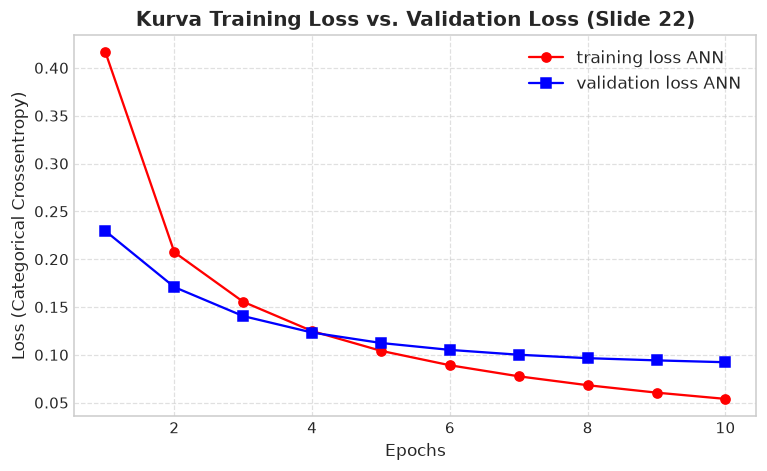

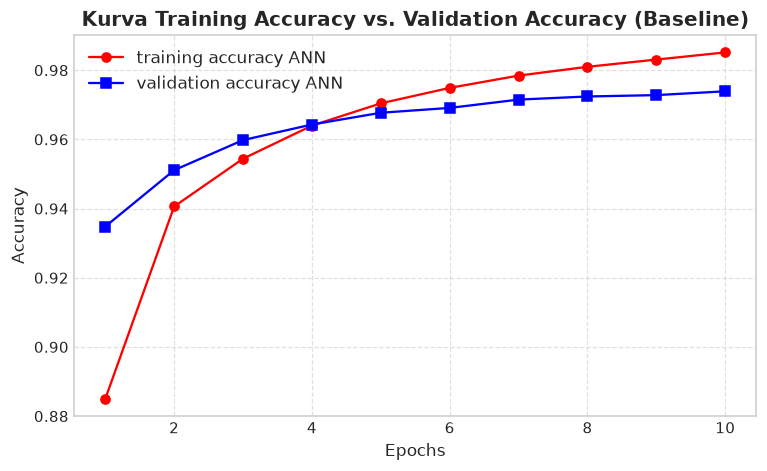

In [6]:
# --- Visualisasi Evaluasi Model Sesuai Slide 22 ---
epochs_range = range(1, 11)
loss1 = history1.history['loss']
val_loss1 = history1.history['val_loss']

plt.figure(figsize=(8, 4.5))
plt.plot(epochs_range, loss1, 'r-o', label='training loss ANN')
plt.plot(epochs_range, val_loss1, 'b-s', label='validation loss ANN')
plt.title('Kurva Training Loss vs. Validation Loss (Slide 22)', fontsize=13, fontweight='bold')
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Loss (Categorical Crossentropy)', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Visualisasi tambahan: Kurva Akurasi
acc_key = 'acc' if 'acc' in history1.history else 'accuracy'
val_acc_key = 'val_acc' if 'val_acc' in history1.history else 'val_accuracy'
acc1 = history1.history[acc_key]
val_acc1 = history1.history[val_acc_key]

plt.figure(figsize=(8, 4.5))
plt.plot(epochs_range, acc1, 'r-o', label='training accuracy ANN')
plt.plot(epochs_range, val_acc1, 'b-s', label='validation accuracy ANN')
plt.title('Kurva Training Accuracy vs. Validation Accuracy (Baseline)', fontsize=13, fontweight='bold')
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Hasil Pengujian Sampel Indeks ke-30 (Slide 23):
label actual    : 3
label prediction: 3


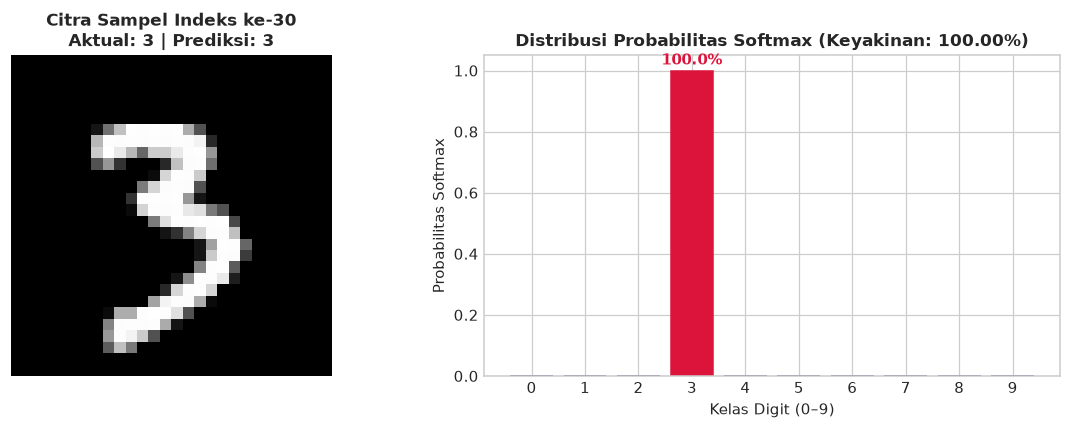

In [7]:
# --- Pemuatan Model & Inferensi Sesuai Slide 23 ---
# Memuat model yang telah disimpan
model_simpan = load_model('my_model.h5')

# Prediksi seluruh data uji
pred = model_simpan.predict(X_test, verbose=0)

# Verifikasi hasil prediksi pada indeks ke-30
sample_idx = 30
actual_lbl = np.argmax(y_test[sample_idx])
pred_lbl = np.argmax(pred[sample_idx])

print(f"Hasil Pengujian Sampel Indeks ke-{sample_idx} (Slide 23):")
print(f"label actual    : {actual_lbl}")
print(f"label prediction: {pred_lbl}")

# Visualisasi citra digit indeks ke-30 beserta batang probabilitas Softmax
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.imshow(X_test[sample_idx].reshape(28, 28), cmap='gray')
ax1.set_title(f"Citra Sampel Indeks ke-{sample_idx}\nAktual: {actual_lbl} | Prediksi: {pred_lbl}", fontsize=11, fontweight='bold')
ax1.axis('off')

bars = ax2.bar(range(10), pred[sample_idx], color='steelblue', edgecolor='midnightblue')
bars[pred_lbl].set_color('crimson')
ax2.set_xlabel('Kelas Digit (0–9)', fontsize=10)
ax2.set_ylabel('Probabilitas Softmax', fontsize=10)
ax2.set_title(f'Distribusi Probabilitas Softmax (Keyakinan: {pred[sample_idx][pred_lbl]*100:.2f}%)', fontsize=11, fontweight='bold')
ax2.set_xticks(range(10))
ax2.set_ylim([0, 1.05])
ax2.text(pred_lbl, pred[sample_idx][pred_lbl] + 0.02, f"{pred[sample_idx][pred_lbl]*100:.1f}%", ha='center', fontweight='bold', color='crimson')
plt.tight_layout()
plt.show()


---
# BAGIAN 2: EKSPERIMEN

Pada bagian ini kita melakukan 5 eksperimen sesuai instruksi berkas tugas:
- **Kasus 2(a):** Regularisasi L1 (*Lasso*)
- **Kasus 2(b):** Regularisasi L2 (*Ridge / Weight Decay*)
- **Kasus 2(c):** Dropout
- **Kasus 2(d):** Early Stopping
- **Kasus 2(e):** Kombinasi L1 Regularization dan Dropout

Setiap eksperimen akan memeriksa:
1. `model.summary()`
2. Nilai performa (*Test Loss* dan *Test Accuracy*)
3. Grafik evaluasi (*Loss chart* dan *Accuracy chart*)
4. Analisis komparatif terhadap model baseline.

Untuk memastikan konsistensi dan visualisasi yang rapi, kita definisikan fungsi pembantu (*helper function*) untuk plotting dan pencatatan riwayat eksperimen.


In [8]:
# Kamus penyimpan hasil seluruh eksperimen untuk analisis komparasi di Bagian III
experiment_results = {}

# Menyimpan hasil model baseline
experiment_results['Baseline (Tanpa Regularisasi)'] = {
    'model': model1,
    'history': history1.history,
    'test_loss': loss_base,
    'test_acc': acc_base,
    'epochs_trained': len(history1.history['loss']),
    'params': model1.count_params(),
    'technique': 'None'
}

def plot_training_history(history, title_prefix, stopped_epoch=None):
    """Fungsi serbaguna untuk menampilkan kurva Loss dan Accuracy secara berdampingan."""
    epochs = range(1, len(history['loss']) + 1)
    acc_key = 'acc' if 'acc' in history else 'accuracy'
    val_acc_key = 'val_acc' if 'val_acc' in history else 'val_accuracy'
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    
    # 1. Kurva Loss
    axes[0].plot(epochs, history['loss'], 'r-o', label='Training Loss', linewidth=1.8, markersize=4)
    axes[0].plot(epochs, history['val_loss'], 'b-s', label='Validation Loss', linewidth=1.8, markersize=4)
    axes[0].set_title(f'Kurva Loss: {title_prefix}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epochs', fontsize=11)
    axes[0].set_ylabel('Loss (Categorical Crossentropy)', fontsize=11)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, linestyle='--', alpha=0.6)
    if stopped_epoch:
        axes[0].axvline(x=stopped_epoch, color='darkgreen', linestyle=':', label=f'Early Stop (Epoch {stopped_epoch})')
        axes[0].legend(fontsize=10)
        
    # 2. Kurva Akurasi
    axes[1].plot(epochs, history[acc_key], 'r-o', label='Training Accuracy', linewidth=1.8, markersize=4)
    axes[1].plot(epochs, history[val_acc_key], 'b-s', label='Validation Accuracy', linewidth=1.8, markersize=4)
    axes[1].set_title(f'Kurva Akurasi: {title_prefix}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epochs', fontsize=11)
    axes[1].set_ylabel('Accuracy', fontsize=11)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, linestyle='--', alpha=0.6)
    if stopped_epoch:
        axes[1].axvline(x=stopped_epoch, color='darkgreen', linestyle=':', label=f'Early Stop (Epoch {stopped_epoch})')
        axes[1].legend(fontsize=10)
        
    plt.tight_layout()
    plt.show()

print("Fungsi helper visualisasi berhasil didefinisikan.")


Fungsi helper visualisasi berhasil didefinisikan.


---
## 2. Kasus 2(a): Regularisasi L1 (Lasso Regularization)

### Teori & Rumusan Matematis:
Regularisasi L1 menambahkan nilai mutlak dari seluruh bobot jaringan (*weight penalty*) ke fungsi *loss* objektif:
$$\mathcal{L}_{L1} = \mathcal{L}_0 + \lambda_1 \sum_{i=1}^{M} |w_i|$$
di mana:
- $\mathcal{L}_0$ adalah *loss* asli (*categorical crossentropy*).
- $\lambda_1$ adalah laju penalti regularisasi L1 (*L1 rate*).
- $w_i$ adalah bobot pada layer tersembunyi.

### Efek Karakteristik L1:
Gradien dari suku penalti L1 bernilai konstan $\pm \lambda_1$ terhadap bobot ($w_i \neq 0$). Hal ini terus mendorong bobot-bobot kecil tepat ke angka nol (**menghasilkan sparsitas bobot / *sparse weights***), sehingga L1 secara intrinsik berfungsi sebagai penyeleksi fitur (*feature selection*).

### Penentuan L1 Rate:
Kita menetapkan **$\lambda_1 = 10^{-4} = 0.0001$**.
- Jika $\lambda_1$ terlalu besar ($> 0.01$), bobot jaringan akan dipaksa menjadi nol secara berlebihan sehingga model mengalami *underfitting*.
- Nilai $0.0001$ merupakan titik seimbang ideal untuk arsitektur MLP 64 neuron dalam menahan *overfitting* tanpa memangkas kapasitas belajar jaringan.


In [9]:
# --- Definisi Model Kasus 2(a): L1 Regularization ---
L1_RATE = 0.0001  # Laju regularisasi L1 yang ditentukan

model_l1 = Sequential([
    Flatten(input_shape=(28, 28, 1), name='flatten_input'),
    Dense(64, activation='relu', kernel_regularizer=l1(L1_RATE), name='hidden_dense_64_l1'),
    Dense(10, activation='softmax', name='output_dense_10')
], name='Model_2a_L1_Regularization')

# Tampilkan ringkasan model
model_l1.summary()


Model: "Model_2a_L1_Regularization"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_input (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_64_l1 (Dense)      │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_10 (Dense)         │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10



  1/550 ━━━━━━━━━━━━━━━━━━━━ 11:47 1s/step - acc: 0.1000 - loss: 2.5903


 16/550 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.4694 - loss: 2.0789  


 29/550 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.5934 - loss: 1.7490


 41/550 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.6476 - loss: 1.5374

...


505/550 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9762 - loss: 0.1701


523/550 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9760 - loss: 0.1705


539/550 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9759 - loss: 0.1708


550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9757 - loss: 0.1709 - val_acc: 0.9723 - val_loss: 0.1781



Hasil Evaluasi Model L1 (Rate = 0.0001) pada Test Set:
Test Loss    : 0.1781
Test Accuracy: 97.23%


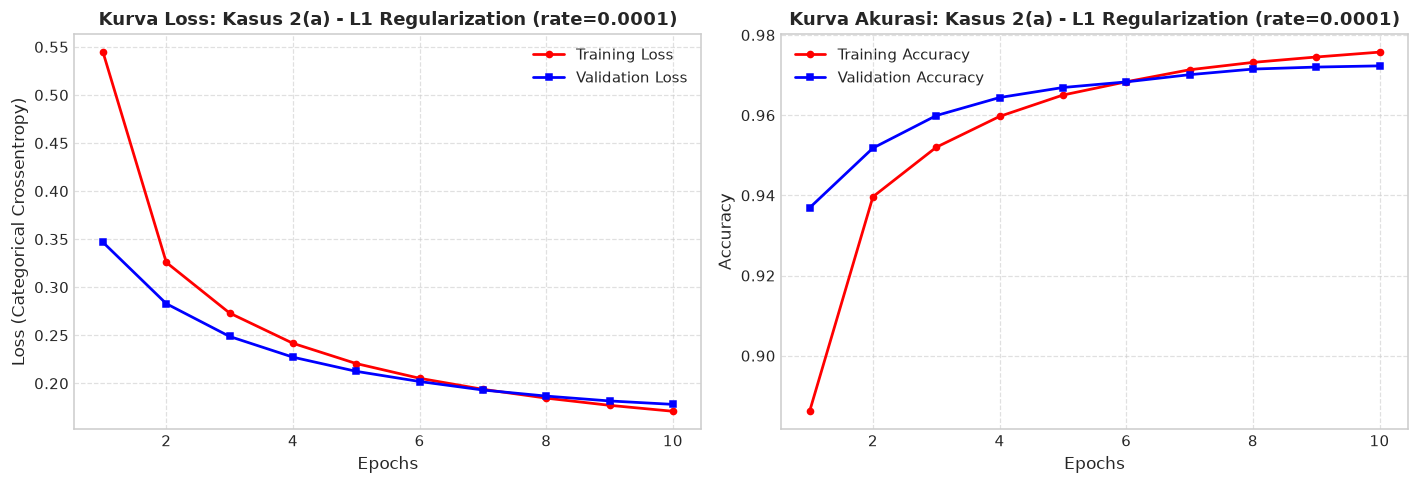

In [10]:
# Kompilasi & Pelatihan Model Kasus 2(a)
model_l1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['acc']
)

history_l1 = model_l1.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=100,
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluasi performa model L1
loss_l1, acc_l1 = model_l1.evaluate(X_test, y_test, verbose=0)
print(f"\nHasil Evaluasi Model L1 (Rate = {L1_RATE}) pada Test Set:")
print(f"Test Loss    : {loss_l1:.4f}")
print(f"Test Accuracy: {acc_l1 * 100:.2f}%")

# Simpan hasil untuk analisis komparatif
experiment_results['Kasus 2(a): L1 Regularization'] = {
    'model': model_l1,
    'history': history_l1.history,
    'test_loss': loss_l1,
    'test_acc': acc_l1,
    'epochs_trained': 10,
    'params': model_l1.count_params(),
    'technique': f'L1 (rate={L1_RATE})'
}

# Tampilkan grafik evaluasi
plot_training_history(history_l1.history, f'Kasus 2(a) - L1 Regularization (rate={L1_RATE})')


---
## 3. Kasus 2(b): Regularisasi L2 (Ridge Regularization / Weight Decay)

### Teori & Rumusan Matematis:
Regularisasi L2 menambahkan jumlah kuadrat dari seluruh parameter bobot ke fungsi *loss* objektif:
$$\mathcal{L}_{L2} = \mathcal{L}_0 + \frac{1}{2} \lambda_2 \sum_{i=1}^{M} w_i^2$$
di mana:
- $\lambda_2$ adalah laju penalti L2 (*weight decay*).

### Efek Karakteristik L2:
Turunan dari suku kuadrat penalti menghasilkan gaya pendorong yang sebanding dengan besaran bobot itu sendiri ($-\lambda_2 w_i$). Bobot yang besar dihukum secara kuadratis, sedangkan bobot yang kecil dihukum sangat minim. Akibatnya:
- L2 **menyusutkan nilai bobot secara halus menuju mendekati nol (*weight shrinkage*)**, tetapi **tidak pernah menghasilkan bobot tepat nol**.
- Jaringan dicegah untuk tidak terlalu bergantung pada satu fitur/neuron tertentu, menyebarkan kontribusi bobot secara merata di seluruh neuron.

### Penentuan L2 Rate:
Kita menetapkan **$\lambda_2 = 10^{-4} = 0.0001$** agar sebanding secara adil (*head-to-head*) dengan laju penalti pada Kasus 2(a).


In [11]:
# --- Definisi Model Kasus 2(b): L2 Regularization ---
L2_RATE = 0.0001  # Laju regularisasi L2 yang ditentukan

model_l2 = Sequential([
    Flatten(input_shape=(28, 28, 1), name='flatten_input'),
    Dense(64, activation='relu', kernel_regularizer=l2(L2_RATE), name='hidden_dense_64_l2'),
    Dense(10, activation='softmax', name='output_dense_10')
], name='Model_2b_L2_Regularization')

# Tampilkan ringkasan model
model_l2.summary()


Model: "Model_2b_L2_Regularization"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_input (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_64_l2 (Dense)      │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_10 (Dense)         │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10



  1/550 ━━━━━━━━━━━━━━━━━━━━ 11:03 1s/step - acc: 0.1300 - loss: 2.3536


 13/550 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.3554 - loss: 1.9789  


 25/550 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.5248 - loss: 1.6655


 40/550 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.6183 - loss: 1.3881

...


513/550 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9830 - loss: 0.0881


528/550 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9830 - loss: 0.0886


541/550 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9830 - loss: 0.0885


550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9830 - loss: 0.0885 - val_acc: 0.9724 - val_loss: 0.1110



Hasil Evaluasi Model L2 (Rate = 0.0001) pada Test Set:
Test Loss    : 0.1110
Test Accuracy: 97.24%


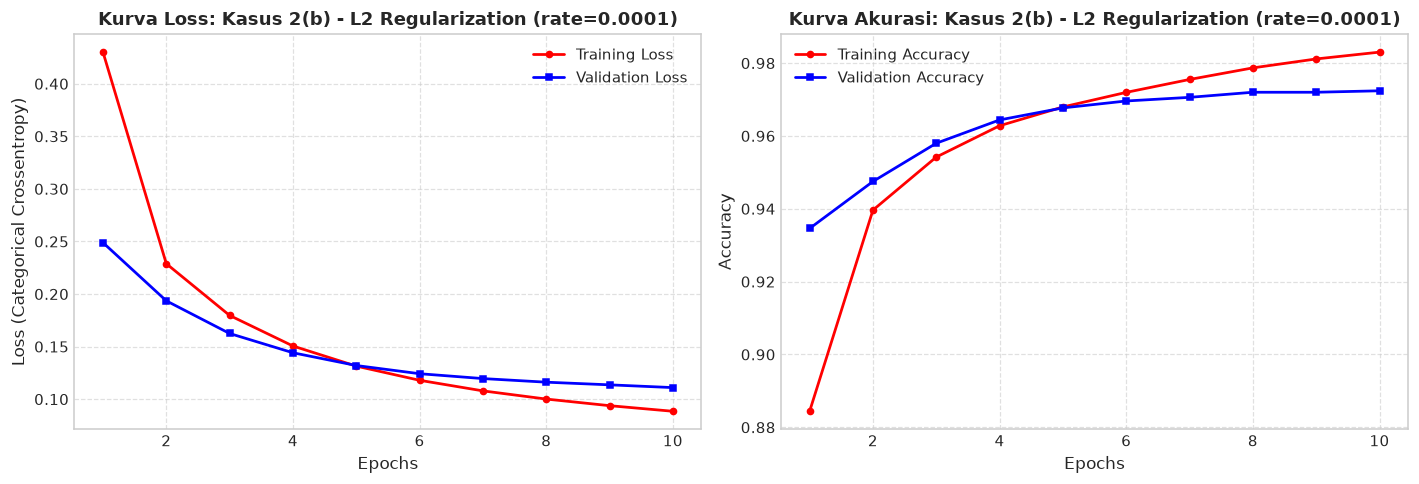

In [12]:
# Kompilasi & Pelatihan Model Kasus 2(b)
model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['acc']
)

history_l2 = model_l2.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=100,
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluasi performa model L2
loss_l2, acc_l2 = model_l2.evaluate(X_test, y_test, verbose=0)
print(f"\nHasil Evaluasi Model L2 (Rate = {L2_RATE}) pada Test Set:")
print(f"Test Loss    : {loss_l2:.4f}")
print(f"Test Accuracy: {acc_l2 * 100:.2f}%")

# Simpan hasil untuk analisis komparatif
experiment_results['Kasus 2(b): L2 Regularization'] = {
    'model': model_l2,
    'history': history_l2.history,
    'test_loss': loss_l2,
    'test_acc': acc_l2,
    'epochs_trained': 10,
    'params': model_l2.count_params(),
    'technique': f'L2 (rate={L2_RATE})'
}

# Tampilkan grafik evaluasi
plot_training_history(history_l2.history, f'Kasus 2(b) - L2 Regularization (rate={L2_RATE})')


---
## 4. Kasus 2(c): Dropout

### Teori & Mekanisme Kerja:
Sesuai penjelasan pada **Slide 30**, *Dropout* bekerja dengan menonaktifkan (*dropping out*) sebagian neuron pada layer secara acak pada setiap iterasi pelatihan dengan probabilitas $p$:
$$r_j \sim \text{Bernoulli}(1 - p)$$
$$\tilde{y}_j = r_j \cdot y_j$$

### Mengapa Dropout Sangat Efektif?
1. **Mencegah Ko-adaptasi Neuron (*Co-adaptation*):** Neuron tidak dapat bergantung pada kehadiran neuron lain secara permanen untuk mengoreksi kesalahannya. Setiap neuron dipaksa belajar fitur-fitur yang mandiri dan berdaya guna (*robust features*).
2. **Efek Ensemble Implisit:** Pada setiap *step*, arsitektur jaringan yang aktif merupakan sub-jaringan acak yang berbeda. Pelatihan dengan dropout secara matematis mendekati rata-rata geometrik (*ensemble*) dari $2^N$ kemungkinan sub-arsitektur.
3. Pada fase evaluasi / pengujian (*inference*), seluruh neuron kembali diaktifkan dan bobot diskalakan secara otomatis (*Inverted Dropout*).

### Penentuan Dropout Rate:
Kita menetapkan **$\text{Dropout Rate} = 0.20$ ($20\%$)** setelah hidden layer (64 neuron).
- Karena lapisan tersembunyi hanya memiliki 64 neuron, rasio $0.20$ (sekitar 13 neuron dinonaktifkan per iterasi) sangat optimal untuk memberikan regularisasi kuat tanpa merusak kapasitas representasi model.


In [13]:
# --- Definisi Model Kasus 2(c): Dropout ---
DROPOUT_RATE = 0.20  # Rasio dropout 20%

model_dropout = Sequential([
    Flatten(input_shape=(28, 28, 1), name='flatten_input'),
    Dense(64, activation='relu', name='hidden_dense_64'),
    Dropout(DROPOUT_RATE, name='dropout_0.20'),  # Layer Dropout
    Dense(10, activation='softmax', name='output_dense_10')
], name='Model_2c_Dropout')

# Tampilkan ringkasan model (Perhatikan: Layer Dropout memiliki 0 parameter)
model_dropout.summary()


Model: "Model_2c_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_input (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_64 (Dense)         │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0.20 (Dropout)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_10 (Dense)         │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10



  1/550 ━━━━━━━━━━━━━━━━━━━━ 10:54 1s/step - acc: 0.0900 - loss: 2.4034


 13/550 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.3100 - loss: 2.0492  


 27/550 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.4841 - loss: 1.7127


 41/550 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.5612 - loss: 1.4790

...


472/550 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9692 - loss: 0.0981


508/550 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9694 - loss: 0.0981


541/550 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9695 - loss: 0.0985


550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9695 - loss: 0.0985 - val_acc: 0.9718 - val_loss: 0.0898



Hasil Evaluasi Model Dropout (Rate = 0.2) pada Test Set:
Test Loss    : 0.0898
Test Accuracy: 97.18%


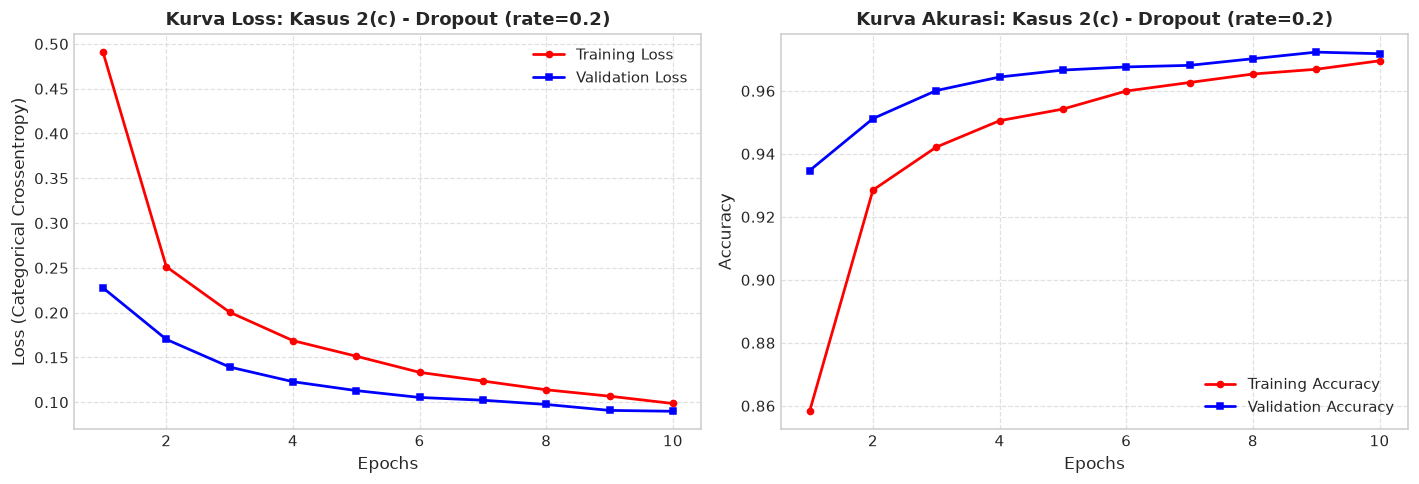

In [14]:
# Kompilasi & Pelatihan Model Kasus 2(c)
model_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['acc']
)

history_dropout = model_dropout.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=100,
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluasi performa model Dropout
loss_dropout, acc_dropout = model_dropout.evaluate(X_test, y_test, verbose=0)
print(f"\nHasil Evaluasi Model Dropout (Rate = {DROPOUT_RATE}) pada Test Set:")
print(f"Test Loss    : {loss_dropout:.4f}")
print(f"Test Accuracy: {acc_dropout * 100:.2f}%")

# Simpan hasil untuk analisis komparatif
experiment_results['Kasus 2(c): Dropout'] = {
    'model': model_dropout,
    'history': history_dropout.history,
    'test_loss': loss_dropout,
    'test_acc': acc_dropout,
    'epochs_trained': 10,
    'params': model_dropout.count_params(),
    'technique': f'Dropout (rate={DROPOUT_RATE})'
}

# Tampilkan grafik evaluasi
plot_training_history(history_dropout.history, f'Kasus 2(c) - Dropout (rate={DROPOUT_RATE})')


---
## 5. Kasus 2(d): Early Stopping

### Teori & Prinsip Kerja:
Sesuai **Slide 30**, *Early Stopping* adalah strategi pembelajaran di mana proses pelatihan dihentikan secara otomatis begitu kesalahan generalisasi (*generalization error* / *validation loss*) mulai mengalami kenaikan meskipun *training loss* terus menurun:
$$\text{Hentikan training jika } \mathcal{L}_{val}^{(t)} \ge \min_{k < t} \mathcal{L}_{val}^{(k)} \text{ selama } K \text{ epoch berturut-turut (patience)}$$

### Keunggulan Early Stopping:
- Tidak mengubah fungsi objektif matematika maupun struktur lapisan jaringan.
- Menghemat daya komputasi secara signifikan.
- Dengan parameter `restore_best_weights=True`, model secara otomatis mengembalikan bobot pada epoch dengan *validation loss* terendah (titik optimal performa generalisasi).

### Konfigurasi Callback Early Stopping:
- `monitor='val_loss'`: Mengawasi pergerakan nilai loss pada data validasi.
- `patience=3`: Memberikan toleransi sebanyak 3 epoch tanpa perbaikan sebelum menghentikan training.
- `restore_best_weights=True`: Memastikan bobot terbaik yang dipertahankan.
- Kita memberikan batas maksimum `epochs=25` agar mekanisme penghentian otomatis memiliki ruang untuk mendeteksi titik jenuh pelatihan.


In [15]:
# --- Definisi Model Kasus 2(d): Early Stopping ---
model_es = Sequential([
    Flatten(input_shape=(28, 28, 1), name='flatten_input'),
    Dense(64, activation='relu', name='hidden_dense_64'),
    Dense(10, activation='softmax', name='output_dense_10')
], name='Model_2d_Early_Stopping')

# Ringkasan arsitektur (identik dengan baseline secara struktural)
model_es.summary()


Model: "Model_2d_Early_Stopping"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_input (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_64 (Dense)         │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_10 (Dense)         │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25



  1/550 ━━━━━━━━━━━━━━━━━━━━ 4:44 518ms/step - acc: 0.1500 - loss: 2.4054


 36/550 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.6300 - loss: 1.4812    


 73/550 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.7378 - loss: 1.0537


108/550 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.7850 - loss: 0.8646

...


550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9928 - loss: 0.0295 - val_acc: 0.9734 - val_loss: 0.0929


Epoch 14: early stopping


Restoring model weights from the end of the best epoch: 11.



Pelatihan dihentikan oleh Early Stopping pada Epoch ke-14.



Hasil Evaluasi Model Early Stopping pada Test Set:
Test Loss    : 0.0910
Test Accuracy: 97.29%


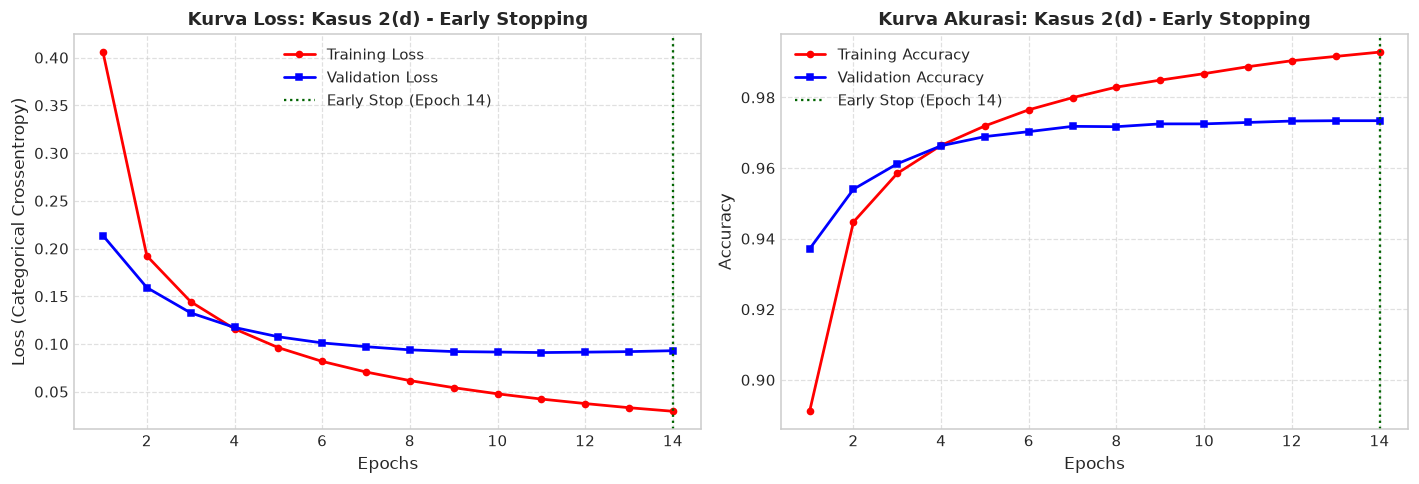

In [16]:
# Konfigurasi EarlyStopping Callback
early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

model_es.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['acc']
)

# Pelatihan model hingga batas maksimum 25 epoch
history_es = model_es.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=100,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping_cb],
    verbose=1
)

stopped_epoch = len(history_es.history['loss'])
print(f"\nPelatihan dihentikan oleh Early Stopping pada Epoch ke-{stopped_epoch}.")

# Evaluasi performa model Early Stopping (dengan bobot terbaik yang dipulihkan)
loss_es, acc_es = model_es.evaluate(X_test, y_test, verbose=0)
print(f"\nHasil Evaluasi Model Early Stopping pada Test Set:")
print(f"Test Loss    : {loss_es:.4f}")
print(f"Test Accuracy: {acc_es * 100:.2f}%")

# Simpan hasil untuk analisis komparatif
experiment_results['Kasus 2(d): Early Stopping'] = {
    'model': model_es,
    'history': history_es.history,
    'test_loss': loss_es,
    'test_acc': acc_es,
    'epochs_trained': stopped_epoch,
    'params': model_es.count_params(),
    'technique': f'Early Stopping (patience=3, stopped={stopped_epoch})'
}

# Tampilkan grafik evaluasi dengan penanda garis epoch berhenti
plot_training_history(history_es.history, 'Kasus 2(d) - Early Stopping', stopped_epoch=stopped_epoch)


---
## 6. Kasus 2(e): Kombinasi Regularisasi L1 dan Dropout

### Teori & Sinergi Dua Metode Regularisasi:
Eksperimen 2(e) menggabungkan dua paradigma regularisasi yang berbeda secara konseptual:
1. **Regularisasi Parameter (L1 Norm):** Menghukum besaran bobot pada tingkat fungsi rugi, mendorong pembentukan representasi yang jarang (*sparse representation*) dan membuang koneksi yang tidak relevan.
2. **Regularisasi Arsitektur (Dropout):** Memutus koneksi informasi antar-neuron secara acak, menghancurkan ketergantungan ko-adaptif.

### Konfigurasi Eksperimen:
- $\text{L1 Rate} = 0.0001$ pada kernel bobot layer `Dense(64)`.
- $\text{Dropout Rate} = 0.20$ setelah layer `Dense(64)`.
- Pelatihan dijalankan selama 10 epoch dengan batch size 100.


In [17]:
# --- Definisi Model Kasus 2(e): L1 Regularization + Dropout ---
model_l1_dropout = Sequential([
    Flatten(input_shape=(28, 28, 1), name='flatten_input'),
    Dense(64, activation='relu', kernel_regularizer=l1(L1_RATE), name='hidden_dense_64_l1'),
    Dropout(DROPOUT_RATE, name='dropout_0.20'),
    Dense(10, activation='softmax', name='output_dense_10')
], name='Model_2e_L1_and_Dropout')

# Tampilkan ringkasan model
model_l1_dropout.summary()


Model: "Model_2e_L1_and_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_input (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_64_l1 (Dense)      │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0.20 (Dropout)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_10 (Dense)         │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10



  1/550 ━━━━━━━━━━━━━━━━━━━━ 6:58 762ms/step - acc: 0.0500 - loss: 2.6254


 33/550 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.5321 - loss: 1.7809    


 64/550 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6491 - loss: 1.3952


 93/550 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7019 - loss: 1.2066

...


449/550 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9587 - loss: 0.2322


485/550 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9589 - loss: 0.2324


523/550 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9587 - loss: 0.2328


550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9585 - loss: 0.2330 - val_acc: 0.9695 - val_loss: 0.1918



Hasil Evaluasi Model L1 + Dropout pada Test Set:
Test Loss    : 0.1918
Test Accuracy: 96.95%


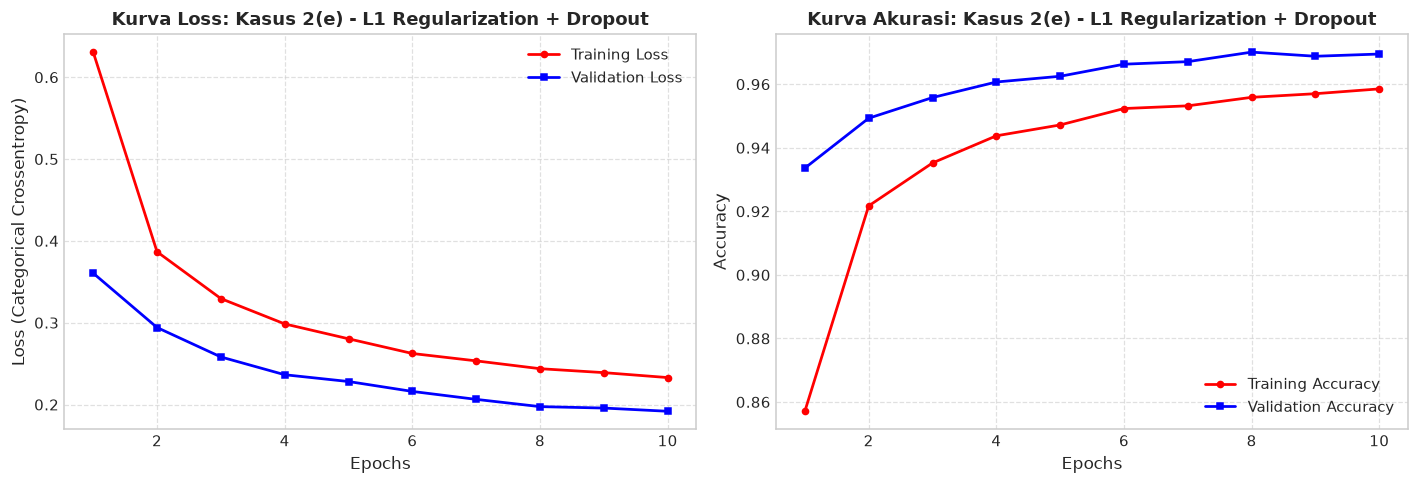

In [18]:
# Kompilasi & Pelatihan Model Kasus 2(e)
model_l1_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['acc']
)

history_l1_dropout = model_l1_dropout.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=100,
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluasi performa model L1 + Dropout
loss_l1_do, acc_l1_do = model_l1_dropout.evaluate(X_test, y_test, verbose=0)
print(f"\nHasil Evaluasi Model L1 + Dropout pada Test Set:")
print(f"Test Loss    : {loss_l1_do:.4f}")
print(f"Test Accuracy: {acc_l1_do * 100:.2f}%")

# Simpan hasil untuk analisis komparatif
experiment_results['Kasus 2(e): L1 + Dropout'] = {
    'model': model_l1_dropout,
    'history': history_l1_dropout.history,
    'test_loss': loss_l1_do,
    'test_acc': acc_l1_do,
    'epochs_trained': 10,
    'params': model_l1_dropout.count_params(),
    'technique': f'L1 (rate={L1_RATE}) + Dropout (rate={DROPOUT_RATE})'
}

# Tampilkan grafik evaluasi
plot_training_history(history_l1_dropout.history, 'Kasus 2(e) - L1 Regularization + Dropout')


---
# BAGIAN 3: ANALISIS KOMPARASI MENYELURUH & EVALUASI

Pada bagian ini, kita menyatukan seluruh metrik kuantitatif dan visualisasi dari seluruh skenario eksperimen (Baseline, 2a, 2b, 2c, 2d, dan 2e) untuk melakukan analisis komparasi mendalam.

Metrik yang dibandingkan:
- **Final Train Loss vs. Test Loss**
- **Final Train Accuracy vs. Test Accuracy**
- **Generalization Gap (Akurasi):** $\Delta \text{Acc} = \text{Train Acc} - \text{Test Acc}$
  *(Semakin kecil gap, semakin minim indikasi overfitting)*
- **Karakteristik Distribusi Bobot (*Weight Sparsity & Shrinkage*)**


In [19]:
import pandas as pd

# Menyusun ringkasan metrik ke dalam DataFrame
summary_data = []

for name, res in experiment_results.items():
    hist = res['history']
    acc_k = 'acc' if 'acc' in hist else 'accuracy'
    val_acc_k = 'val_acc' if 'val_acc' in hist else 'val_accuracy'
    
    final_tr_loss = hist['loss'][-1]
    final_val_loss = hist['val_loss'][-1]
    final_tr_acc = hist[acc_k][-1]
    final_val_acc = hist[val_acc_k][-1]
    
    gen_gap_acc = (final_tr_acc - res['test_acc']) * 100
    
    summary_data.append({
        'Skenario Eksperimen': name,
        'Teknik Regularisasi': res['technique'],
        'Epoch': res['epochs_trained'],
        'Total Parameter': res['params'],
        'Train Loss': f"{final_tr_loss:.4f}",
        'Test Loss': f"{res['test_loss']:.4f}",
        'Train Acc (%)': f"{final_tr_acc * 100:.2f}%",
        'Test Acc (%)': f"{res['test_acc'] * 100:.2f}%",
        'Generalization Gap (%)': f"{gen_gap_acc:+.2f}%"
    })

df_summary = pd.DataFrame(summary_data)
# Tampilkan tabel komparasi
df_summary


,Skenario Eksperimen,Teknik Regularisasi,Epoch,Total Parameter,Train Loss,Test Loss,Train Acc (%),Test Acc (%),Generalization Gap (%)
0,Baseline (Tanpa Regularisasi),None,10,50890,0.0539,0.0923,98.51%,97.39%,+1.12%
1,Kasus 2(a): L1 Regularization,L1 (rate=0.0001),10,50890,0.1709,0.1781,97.57%,97.23%,+0.34%
2,Kasus 2(b): L2 Regularization,L2 (rate=0.0001),10,50890,0.0885,0.1110,98.30%,97.24%,+1.06%
3,Kasus 2(c): Dropout,Dropout (rate=0.2),10,50890,0.0985,0.0898,96.95%,97.18%,-0.23%
4,Kasus 2(d): Early Stopping,"Early Stopping (patience=3, stopped=14)",14,50890,0.0295,0.0910,99.28%,97.29%,+1.99%
5,Kasus 2(e): L1 + Dropout,L1 (rate=0.0001) + Dropout (rate=0.2),10,50890,0.2330,0.1918,95.85%,96.95%,-1.10%


### Visualisasi Gabungan: Perbandingan Seluruh Kurva Validasi
Plotting seluruh kurva validasi pada satu diagram memungkinkan perbandingan visual yang presisi mengenai stabilitas numerik dan laju konvergensi masing-masing strategi pembelajaran.


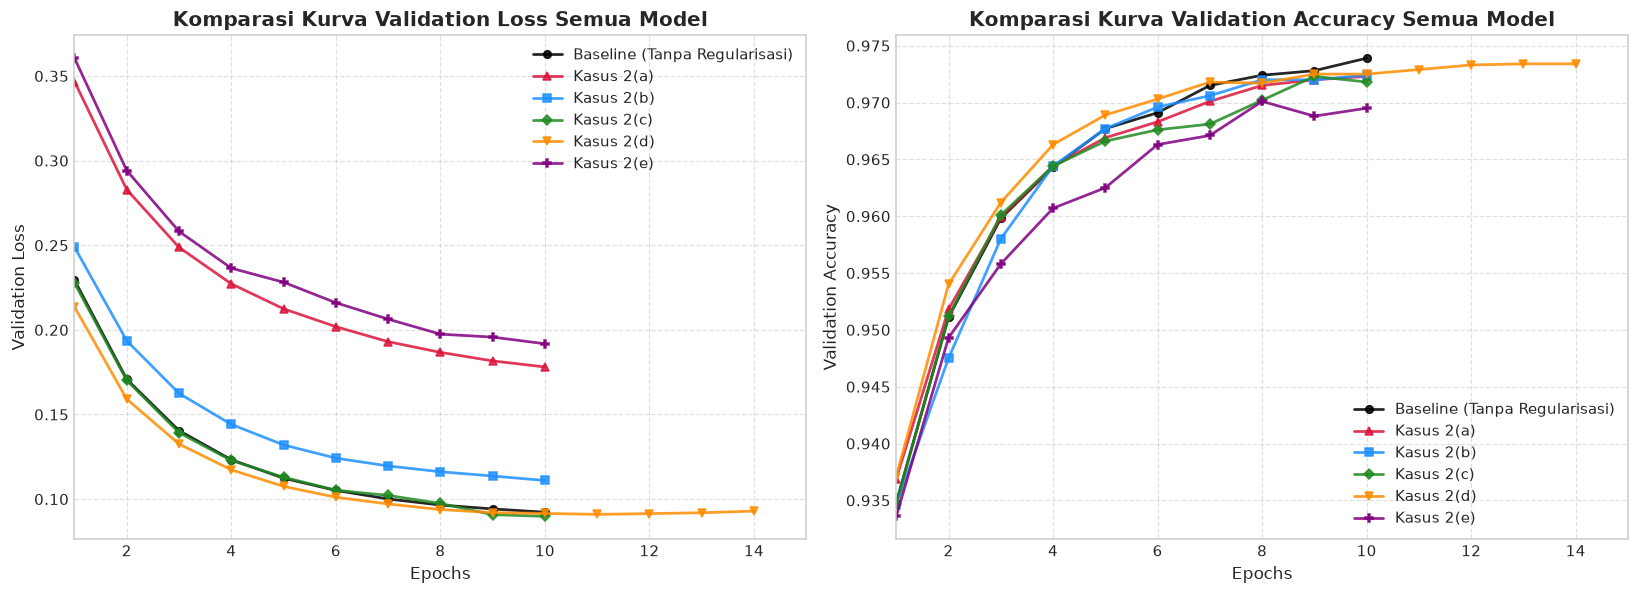

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

colors = {
    'Baseline (Tanpa Regularisasi)': 'black',
    'Kasus 2(a): L1 Regularization': 'crimson',
    'Kasus 2(b): L2 Regularization': 'dodgerblue',
    'Kasus 2(c): Dropout': 'forestgreen',
    'Kasus 2(d): Early Stopping': 'darkorange',
    'Kasus 2(e): L1 + Dropout': 'purple'
}

markers = {
    'Baseline (Tanpa Regularisasi)': 'o',
    'Kasus 2(a): L1 Regularization': '^',
    'Kasus 2(b): L2 Regularization': 's',
    'Kasus 2(c): Dropout': 'D',
    'Kasus 2(d): Early Stopping': 'v',
    'Kasus 2(e): L1 + Dropout': 'P'
}

# 1. Plot Semua Validation Loss
for name, res in experiment_results.items():
    vl = res['history']['val_loss']
    ax1.plot(range(1, len(vl) + 1), vl, label=name.split(':')[0],
             color=colors[name], marker=markers[name], markersize=5, linewidth=1.8, alpha=0.85)

ax1.set_title('Komparasi Kurva Validation Loss Semua Model', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=11)
ax1.set_ylabel('Validation Loss', fontsize=11)
ax1.set_xlim([1, 15])
ax1.legend(fontsize=9.5, loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# 2. Plot Semua Validation Accuracy
for name, res in experiment_results.items():
    hist = res['history']
    val_acc_k = 'val_acc' if 'val_acc' in hist else 'val_accuracy'
    va = hist[val_acc_k]
    ax2.plot(range(1, len(va) + 1), va, label=name.split(':')[0],
             color=colors[name], marker=markers[name], markersize=5, linewidth=1.8, alpha=0.85)

ax2.set_title('Komparasi Kurva Validation Accuracy Semua Model', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=11)
ax2.set_ylabel('Validation Accuracy', fontsize=11)
ax2.set_xlim([1, 15])
ax2.legend(fontsize=9.5, loc='lower right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### Analisis Pembuktian Empiris: Histogram Distribusi Bobot
Salah satu perbedaan paling fundamental antara **L1** dan **L2** adalah bagaimana kedua teknik tersebut mempengaruhi nilai bobot internal model:
- **Baseline:** Bobot terdistribusi normal tanpa dorongan menuju nol.
- **L1 (Lasso):** Menghasilkan lonjakan ekstrem tepat di sekitar nol (**sparsitas bobot**), membuktikan eliminasi fitur yang tidak informatif.
- **L2 (Weight Decay):** Menekan varians bobot secara keseluruhan, membuat rentang sebaran bobot menjadi lebih sempit dan kompak (*shrinkage*).


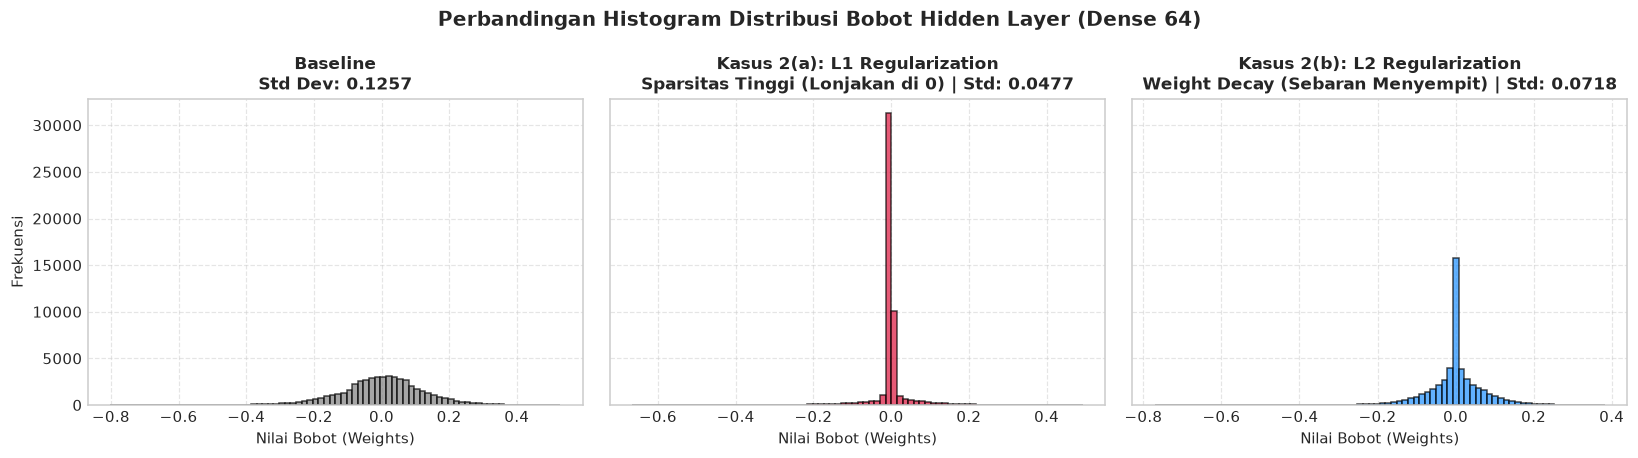

Persentase Bobot Mendekati Nol (|w| < 0.005):
- Baseline           : 3.53%
- L1 Regularization  : 67.38%  <-- Bukti empiris fenomena Sparsitas L1
- L2 Regularization  : 28.61%


In [21]:
# Ekstraksi bobot layer tersembunyi (Hidden Layer Dense)
w_base = model1.get_layer('hidden_dense_64').get_weights()[0].flatten()
w_l1 = model_l1.get_layer('hidden_dense_64_l1').get_weights()[0].flatten()
w_l2 = model_l2.get_layer('hidden_dense_64_l2').get_weights()[0].flatten()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

# 1. Baseline
axes[0].hist(w_base, bins=80, color='gray', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Baseline\nStd Dev: {np.std(w_base):.4f}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Nilai Bobot (Weights)', fontsize=10)
axes[0].set_ylabel('Frekuensi', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. L1 Regularization (Perhatikan lonjakan densitas di sekitar nilai 0)
axes[1].hist(w_l1, bins=80, color='crimson', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Kasus 2(a): L1 Regularization\nSparsitas Tinggi (Lonjakan di 0) | Std: {np.std(w_l1):.4f}', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Nilai Bobot (Weights)', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. L2 Regularization (Perhatikan penyusutan rentang bobot)
axes[2].hist(w_l2, bins=80, color='dodgerblue', edgecolor='black', alpha=0.7)
axes[2].set_title(f'Kasus 2(b): L2 Regularization\nWeight Decay (Sebaran Menyempit) | Std: {np.std(w_l2):.4f}', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Nilai Bobot (Weights)', fontsize=10)
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Perbandingan Histogram Distribusi Bobot Hidden Layer (Dense 64)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Hitung persentase bobot yang mendekati nol (|w| < 0.005)
pct_zero_base = np.mean(np.abs(w_base) < 0.005) * 100
pct_zero_l1   = np.mean(np.abs(w_l1) < 0.005) * 100
pct_zero_l2   = np.mean(np.abs(w_l2) < 0.005) * 100

print(f"Persentase Bobot Mendekati Nol (|w| < 0.005):")
print(f"- Baseline           : {pct_zero_base:.2f}%")
print(f"- L1 Regularization  : {pct_zero_l1:.2f}%  <-- Bukti empiris fenomena Sparsitas L1")
print(f"- L2 Regularization  : {pct_zero_l2:.2f}%")
